In [65]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import vector

In [5]:
file = uproot.open('mc_110909.ZPrime2500.root')

In [10]:
file2 = uproot.open('mc_117049.ttbar_had.root')

In [11]:
file.keys()
file2.keys()

['mini;1']

In [42]:
tree = file["mini"]
tree2 = file2["mini"]
tree.keys()



['runNumber',
 'eventNumber',
 'channelNumber',
 'mcWeight',
 'pvxp_n',
 'vxp_z',
 'scaleFactor_PILEUP',
 'scaleFactor_ELE',
 'scaleFactor_MUON',
 'scaleFactor_BTAG',
 'scaleFactor_TRIGGER',
 'scaleFactor_JVFSF',
 'scaleFactor_ZVERTEX',
 'trigE',
 'trigM',
 'passGRL',
 'hasGoodVertex',
 'lep_n',
 'lep_truthMatched',
 'lep_trigMatched',
 'lep_pt',
 'lep_eta',
 'lep_phi',
 'lep_E',
 'lep_z0',
 'lep_charge',
 'lep_type',
 'lep_flag',
 'lep_ptcone30',
 'lep_etcone20',
 'lep_trackd0pvunbiased',
 'lep_tracksigd0pvunbiased',
 'met_et',
 'met_phi',
 'jet_n',
 'alljet_n',
 'jet_pt',
 'jet_eta',
 'jet_phi',
 'jet_E',
 'jet_m',
 'jet_jvf',
 'jet_trueflav',
 'jet_truthMatched',
 'jet_SV0',
 'jet_MV1']

In [128]:
branches = tree.arrays()
branches2 = tree2.arrays()
branches2['mcWeight']

<Array [1, 1, 1, 1, 1, 1, ... 1, 1, 1, 1, 1, 1] type='25170 * float32'>

In [118]:
xx = branches['jet_n'] != 0
xx2 = branches2['jet_n'] != 0
branches = branches[xx]
branches2 = branches2[xx2]

In [97]:
max(branches2['jet_E'])

ValueError: operands could not be broadcast together with shapes (1,4) (1,5) 

In [98]:
max(ak.flatten(branches2['jet_E']))

1971930.5

In [40]:
print(len(ak.flatten(branches['jet_trueflav'])))
np.count_nonzero(ak.flatten(branches['jet_trueflav']) == 5)

87825


33173

In [38]:
print(len(ak.flatten(branches2['jet_trueflav'])))
np.count_nonzero(ak.flatten(branches2['jet_trueflav']) == 5)

114434


22804

In [126]:
btag = branches['jet_trueflav'] == 5
btag2 = branches2['jet_trueflav'] == 5

In [95]:
def plot_diff(hist1,hist2,lowlimit,uplimit,bins,name):
    (n, bins, patches)=plt.hist([hist1,hist2], bins,color=["r","g"], range =[lowlimit,uplimit], 
                            density=True, histtype='step',label=["sig","bkg"])
    plt.xlabel(name)
    plt.legend()

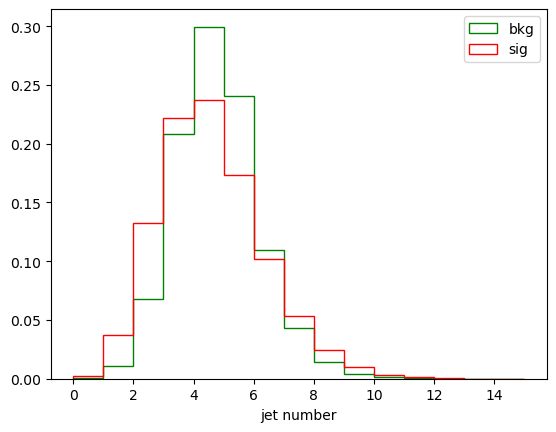

In [71]:
plot_diff(branches['jet_n'],branches2['jet_n'],15,15,"jet number")

In [114]:
def divide1(ori):
    x = []
    for i in ori: x.append(i/1000)
    return x
def count_btag(ori):
    x = []
    for i in ori:
        n = 0
        for j in i:
            if j == 5:n+=1
        x.append(n)
    return x
def take_max(ori):
    x = []
    for i in ori:x.append(max(i))
    return x

In [121]:
btag1 = count_btag(branches['jet_trueflav'])
btag2 = count_btag(branches2['jet_trueflav'])

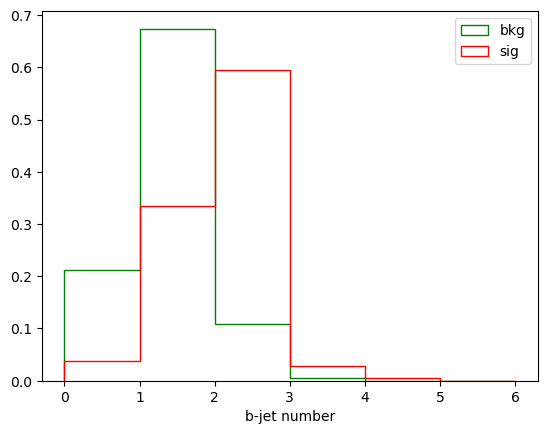

In [75]:
plot_diff(btag1,btag2,6,6,"b-jet number")

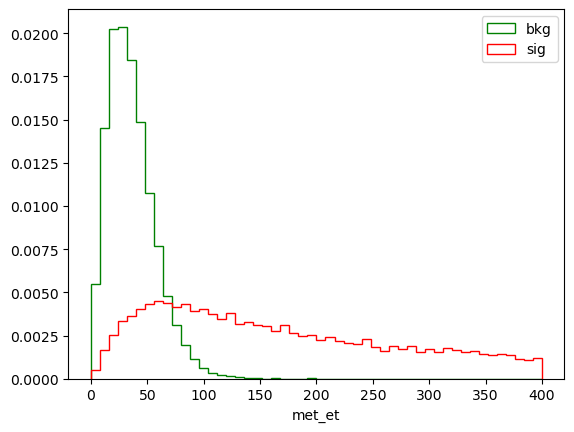

In [91]:
met_et1 = divide1(branches['met_et'])
met_et2 = divide1(branches2['met_et'])
plot_diff(met_et1,met_et2,400,50,'met_et')#hist1,hist2,limit,bins,name

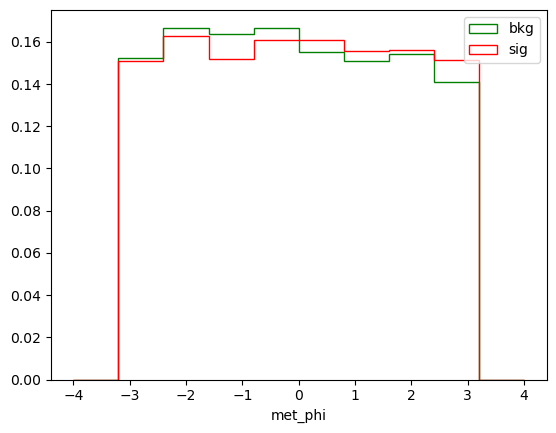

In [96]:
plot_diff(branches['met_phi'],branches2['met_phi'],-4,4,10,'met_phi')#hist1,hist2,lowlimit,uplimit,bins,name

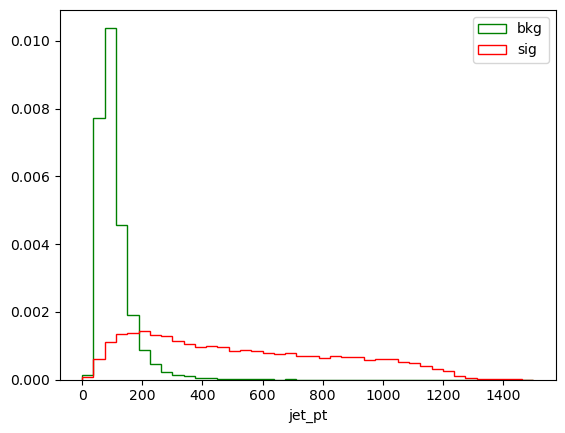

In [119]:
x = divide1(take_max(branches['jet_pt']))
y = divide1(take_max(branches2['jet_pt']))
plot_diff(x,y,0,1500,40,'leading_jet_pt')#hist1,hist2,lowlimit,uplimit,bins,name

In [127]:
x = divide1(take_max(branches['jet_pt'][btag]))
y = divide1(take_max(branches2['jet_pt'][btag2]))
plot_diff(x,y,0,1500,40,'bjet_pt')#hist1,hist2,lowlimit,uplimit,bins,name

ValueError: max() arg is an empty sequence